In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.sparse import csc_matrix
from sksparse.cholmod import cholesky
import time

Importazione matrice e termine noto del sistema lineare:

In [2]:
def ImportaMatriceCSC(N, tipo_ordinamento):
    file_da_leggere = f"../dati/A{N}{tipo_ordinamento}.txt"

    r, c, v = np.loadtxt(file_da_leggere, unpack=True)
    r = r.astype(np.int32)      # di default sono float
    c = c.astype(np.int32)

    A_csc = csc_matrix((v,(r,c)), shape=(N**2, N**2))

    return A_csc

def ImportaRhs(N, tipo_ordinamento):
    file_da_leggere = f"../dati/rhs{N}{tipo_ordinamento}.txt"

    b = np.loadtxt(file_da_leggere)
    
    return b

Funzioni per la fattorizzazione e la soluzione del sistema lineare:

In [3]:
def CalcolaCholesky(A):
    factor = cholesky(A, ordering_method="natural")
    return csc_matrix(factor.L())

In [4]:
def RisolviSistema(L, b):
    y = scipy.sparse.linalg.spsolve_triangular(L, -b)
    u = scipy.sparse.linalg.spsolve_triangular(L.T, y, lower=False)
    return u

Funzioni per passare da ordine naturale/riordinato dei nodi interni a (i,j), e dall'ordine del bordo a (i,j):

In [5]:
def GeneraMappaNaturale(N):                         # mappa da n (ordine naturale) a (i,j)
    file_da_leggere = f"../dati/coords{N}.txt"

    mappa_nat_inv = np.loadtxt(file_da_leggere, usecols=(1, 2), dtype=np.int32)

    return mappa_nat_inv

def GeneraMappaOrdinata(N):                         # mappa da m (riordinamento) a (i,j)
    file_da_leggere = f"../dati/ordering{N}.txt"

    mappa_m_n = np.loadtxt(file_da_leggere, usecols=(1), dtype=np.int32)

    mappa_nat_inv = GeneraMappaNaturale(N)

    mappa_ord_inv = mappa_nat_inv[mappa_m_n]

    return mappa_ord_inv

def GeneraMappaBordo(N):                            # mappa da {0,...,4N+3} a (i,j) del bordo
    mappa = np.zeros((4 * N + 4, 2), dtype=np.int32)

    k1 = np.arange(0, N+2)          # lato sinistro
    mappa[k1, 0] = 0
    mappa[k1, 1] = k1

    k2 = np.arange(N+2, 2*N+3)      # lato in alto
    mappa[k2, 0] = k2 - (N + 1)
    mappa[k2, 1] = N + 1

    k3 = np.arange(2*N+3, 3*N+4)    # lato a destra 
    mappa[k3, 0] = N + 1
    mappa[k3, 1] = 3*N + 3 - k3

    k4 = np.arange(3*N+4, 4*N+4)    # lato in basso
    mappa[k4, 0] = 4*N + 4 - k4
    mappa[k4, 1] = 0

    return mappa

Funzione per disegnare la soluzione:

In [6]:
def DisegnaSoluzione(N, tipo_ordinamento, u, u0 = None):
    
    h = 1.0 / (N + 1)       # passo del reticolo
    
    if u0 is None:                  # di default i valori sul bordo sono 0
        u0 = np.zeros(4*N + 4)

    mappa_bordo = GeneraMappaBordo(N)

    if tipo_ordinamento == "nat":
        mappa_interna = GeneraMappaNaturale(N)
    elif tipo_ordinamento == "ord":
        mappa_interna = GeneraMappaOrdinata(N)

    coord = np.vstack((mappa_interna, mappa_bordo))
    x = coord[:,0] * h
    y = coord[:,1] * h

    sol = np.concatenate((u,u0))

    plt.figure()
    plt.scatter(x, y, c = sol, cmap = 'jet', s = 2)
    plt.colorbar(label = "Temperatura")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0,1)
    plt.ylim(0,1)

    plt.show()

Esempio di struttura delle matrici $A,L$:

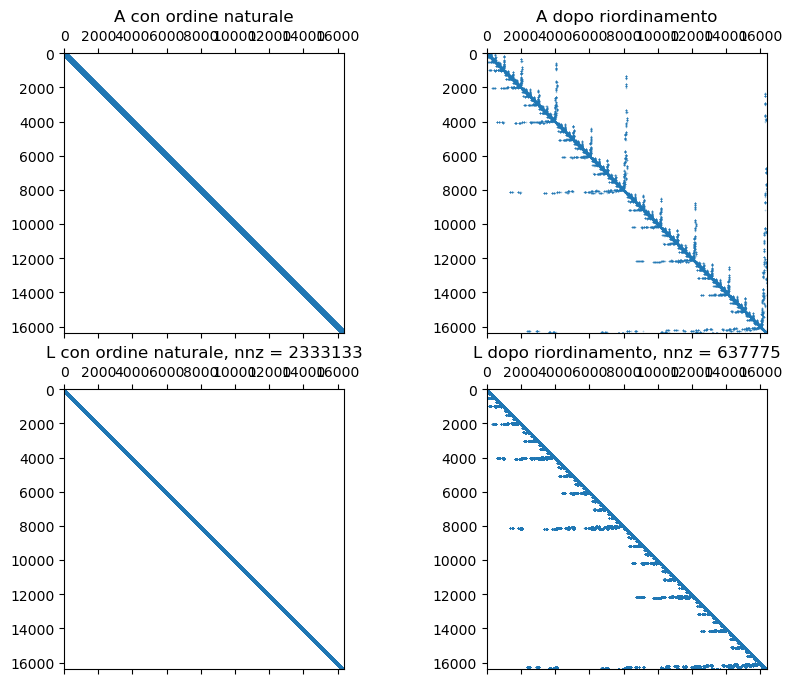

In [31]:
N = 128

A1 = ImportaMatriceCSC(N, "nat")
L1 = CalcolaCholesky(-A1)

A2 = ImportaMatriceCSC(N, "ord")
L2 = CalcolaCholesky(-A2)

plt.figure(figsize=(10, 8))
plt.subplot(2,2,1)
plt.spy(A1, markersize = 0.1)
plt.title("A con ordine naturale")

plt.subplot(2,2,2)
plt.spy(A2, markersize = 0.1)
plt.title("A dopo riordinamento")

plt.subplot(2,2,3)
plt.spy(L1, markersize = 0.1)
n1 = L1.nnz
plt.title(f"L con ordine naturale, nnz = {n1}")

plt.subplot(2,2,4)
plt.spy(L2, markersize = 0.1)
n2 = L2.nnz
plt.title(f"L dopo riordinamento, nnz = {n2}")
plt.show()

Esempio di grafico della soluzione:

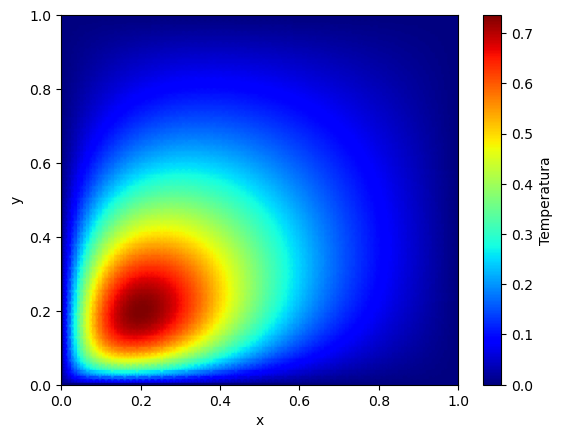

In [34]:
N = 256
tipo_ordinamento = "ord"        # il grafico della soluzione chiaramente non dipende dall'ordinamento

A = ImportaMatriceCSC(N, tipo_ordinamento)
b = ImportaRhs(N, tipo_ordinamento)
L = CalcolaCholesky(-A)
u = RisolviSistema(L, b)

DisegnaSoluzione(N, tipo_ordinamento, u)

Calcolo del tempo necessario e delle entrate non nulle di L, al variare di N e dell'ordinamento:

In [ ]:
valori_N = [2**n for n in range(5, 11)]
ordinamenti = ["nat", "ord"]

tempi_Cholesky = {"nat": [], "ord": []}
tempi_sol = {"nat": [], "ord": []}
nnz = {"nat": [], "ord": []}

for N in valori_N:
    if N<=512:                          # per N = 1024, l'ordinamento naturale richiede troppo tempo
        for tipo_ord in ordinamenti:
            A = ImportaMatriceCSC(N, tipo_ord)
            b = ImportaRhs(N, tipo_ord)

            t0 = time.perf_counter()
            L = CalcolaCholesky(-A)
            t1 = time.perf_counter()
            u = RisolviSistema(L, b)
            t2 = time.perf_counter()

            tempi_Cholesky[tipo_ord].append(t1 - t0)
            tempi_sol[tipo_ord].append(t2 - t1)
            nnz[tipo_ord].append(L.nnz)
    else:
        tipo_ord = "ord"
        A = ImportaMatriceCSC(N, tipo_ord)
        b = ImportaRhs(N, tipo_ord)

        t0 = time.perf_counter()
        L = CalcolaCholesky(-A)
        t1 = time.perf_counter()
        u = RisolviSistema(L, b)
        t2 = time.perf_counter()

        tempi_Cholesky[tipo_ord].append(t1 - t0)
        tempi_sol[tipo_ord].append(t2 - t1)
        nnz[tipo_ord].append(L.nnz)

Grafici dei tempi:

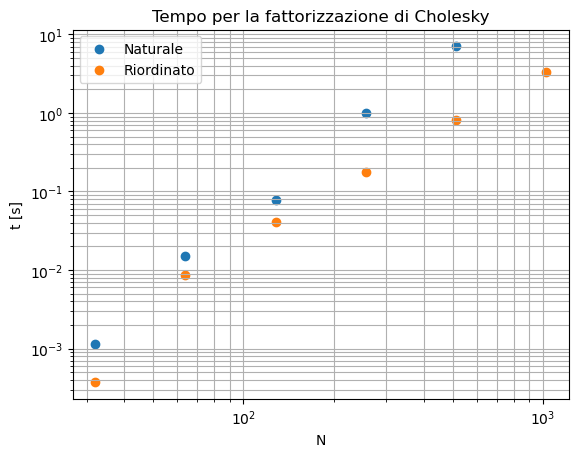

In [17]:
plt.figure()
plt.scatter(valori_N[0:5], tempi_Cholesky["nat"])
plt.scatter(valori_N, tempi_Cholesky["ord"])
plt.xscale("log")
plt.yscale("log")
plt.title("Tempo per la fattorizzazione di Cholesky")
plt.xlabel("N")
plt.ylabel("t [s]")
plt.legend(["Naturale", "Riordinato"])
plt.grid(True, which='both')

plt.show()

Il caso naturale sembra una retta con pendenza circa 3.2; dovrebbe essere forse $O(N^4)$. Il caso riordinato ha un primo punto stranamente basso, poi ha pendenza circa 2.2; dovrebbe essere forse $O(N^3)$.

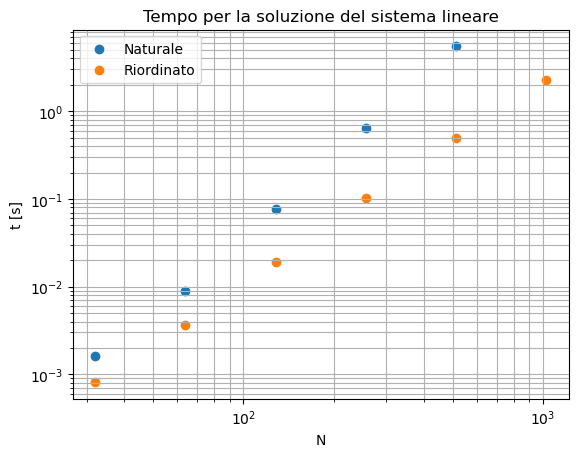

In [18]:
plt.figure()
plt.scatter(valori_N[0:5], tempi_sol["nat"])
plt.scatter(valori_N, tempi_sol["ord"])
plt.xscale("log")
plt.yscale("log")
plt.title("Tempo per la soluzione del sistema lineare")
plt.xlabel("N")
plt.ylabel("t [s]")
plt.legend(["Naturale", "Riordinato"])
plt.grid(True, which="both")

plt.show()

Il caso naturale sembra una retta con pendenza 3, cioè $O(N^3)$. Il caso riordinato non dovrebbe essere una retta, dovrebbe essere $O(N^2 \log N)$; approssimando con una retta, ha pendenza circa 2.4.

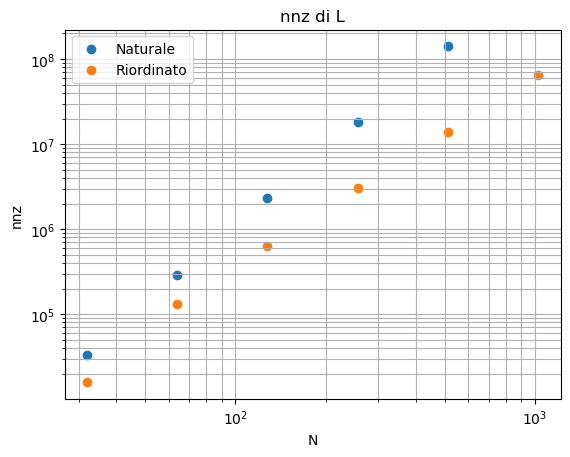

In [19]:
plt.figure()
plt.scatter(valori_N[0:5], nnz["nat"])
plt.scatter(valori_N, nnz["ord"])
plt.xscale("log")
plt.yscale("log")
plt.title("nnz di L")
plt.xlabel("N")
plt.ylabel("nnz")
plt.legend(["Naturale", "Riordinato"])
plt.grid(True, which="both")

plt.show()

E' circa uguale al tempo per il sistema lineare.